In [1]:
############# Explore Beaufort Shelfbreak Precipitation #############
# The purpose of this script is to explore the precipitation 
# conditions in a box on the Beaufort Sea shelfbreak 
# jet so use as inputs for the idealized mode. Precipitation will be
# a timeseries 
# that is an idealized version of the data. This analysis will be 
# based on ERA5 data.
#
# Notes:
# -
#
######################################################################

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
# Load in the packages
import xarray as xr
import numpy as np
import cartopy
import glob
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
import warnings
import numpy as np
from netCDF4 import Dataset
import datetime
from datetime import datetime
import matplotlib.dates as mdates
import pandas as pd
import xroms
from matplotlib import ticker
crs = ccrs.PlateCarree()
warnings.filterwarnings("ignore") 
#Cartopy
land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                edgecolor='face',
                                facecolor=cfeature.COLORS['land'])

from xhistogram.xarray import histogram

In [3]:
# Load in the ERA5 sea level pressure data
era5_precip = xr.open_dataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_2020_dvd_myroms_ice_scratch/External_data/ERA5_data/tot_mean_precip_rate_era5_2017_2024.nc')
era5_precip

<xarray.Dataset> Size: 454MB
Dimensions:     (valid_time: 70128, longitude: 77, latitude: 21)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 561kB 2017-01-01 ... 2024-12-31T2...
  * longitude   (longitude) float64 616B -156.0 -155.8 -155.5 ... -137.2 -137.0
  * latitude    (latitude) float64 168B 73.0 72.75 72.5 ... 68.5 68.25 68.0
Data variables:
    avg_tprate  (valid_time, latitude, longitude) float32 454MB ...
Attributes:
    CDI:                     Climate Data Interface version 2.5.0 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Thu Aug 07 14:35:36 2025: cdo mergetime tot_mean...
    CDO:                     Climate Data Operators version 2.5.0 (https://mp...

In [4]:
era5_precip.avg_tprate

<xarray.DataArray 'avg_tprate' (valid_time: 70128, latitude: 21, longitude: 77)> Size: 454MB
[113396976 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 561kB 2017-01-01 ... 2024-12-31T2...
  * longitude   (longitude) float64 616B -156.0 -155.8 -155.5 ... -137.2 -137.0
  * latitude    (latitude) float64 168B 73.0 72.75 72.5 ... 68.5 68.25 68.0
Attributes: (12/32)
    standard_name:                            unknown
    long_name:                                Time-mean total precipitation rate
    units:                                    kg m**-2 s**-1
    GRIB_paramId:                             235055
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1617
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Time-mean total precipitation rate
    GRIB_shortName:                           avg_tprate
    GRIB_totalNumber:                         0
    GRIB_units:                               kg m**-2 s**-1
    GRIB_surface:                             0.0

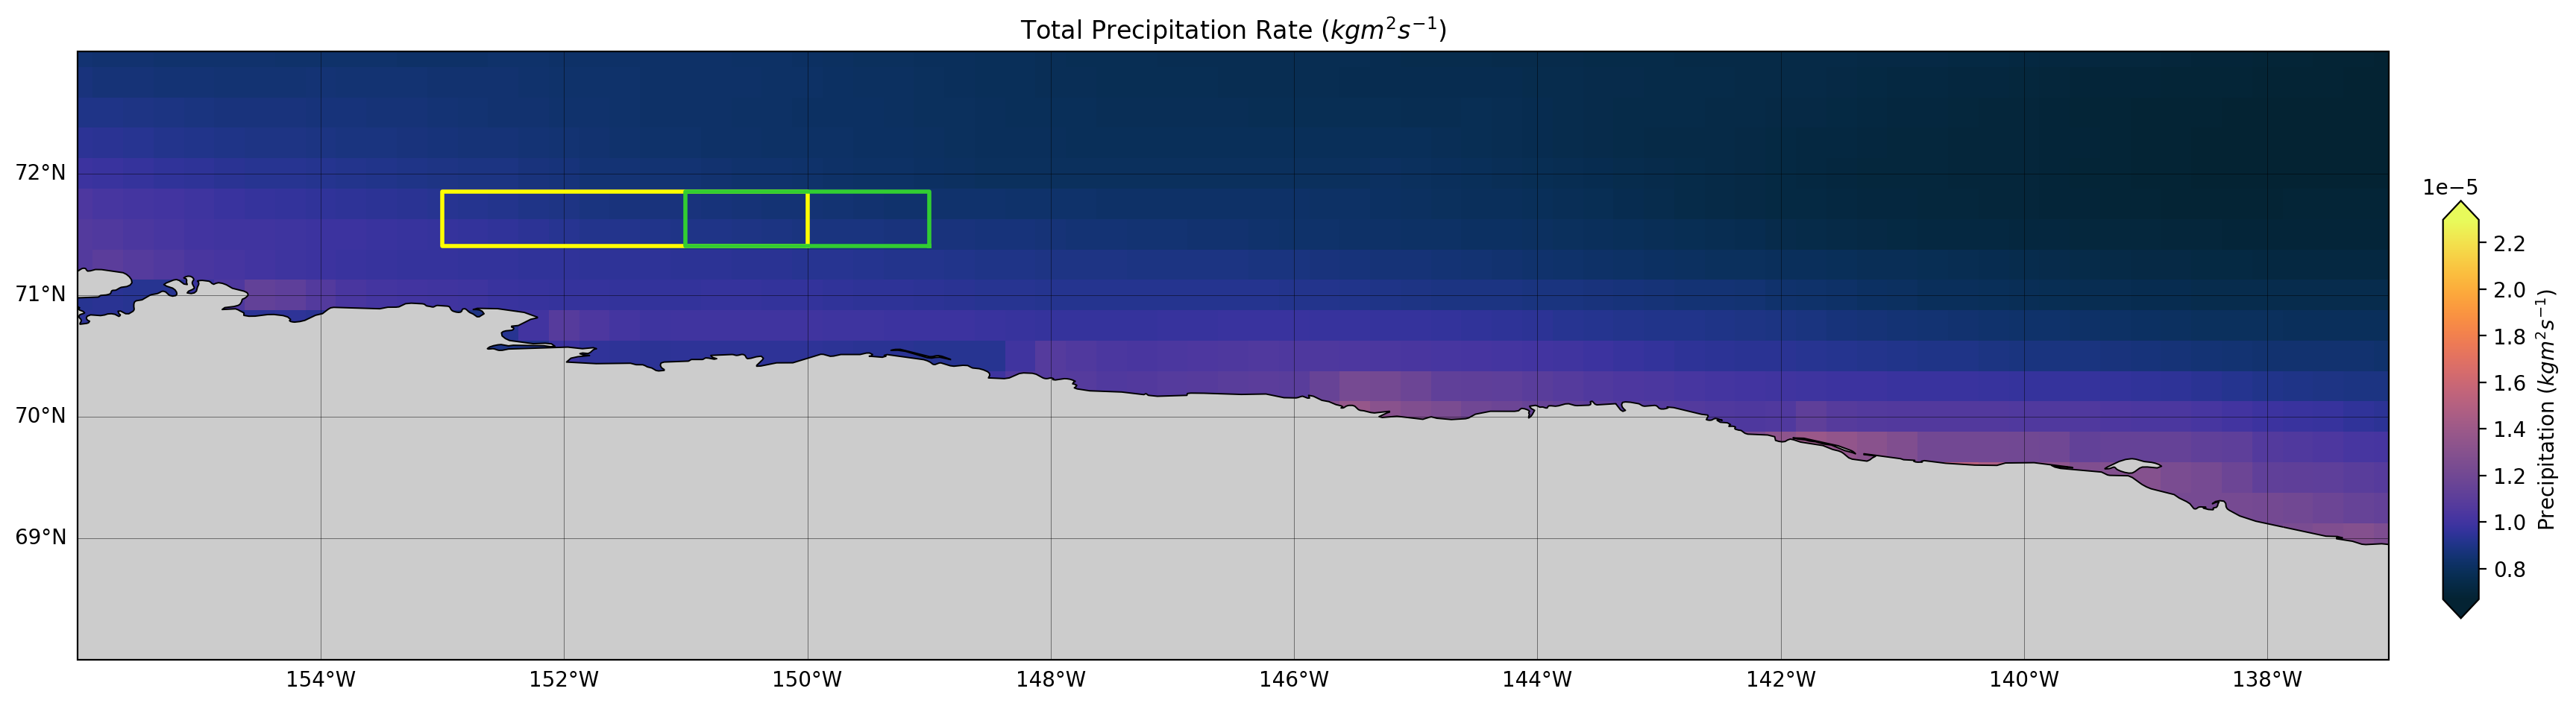

In [9]:
# Plot means
# Put both boxes

# Make bathymetry levels
lev_bathy = np.arange(10,110,10)

# Make the figure 
fig, ax = plt.subplots(figsize=(16,8), dpi=200,
                       constrained_layout=True, 
                       subplot_kw={'projection': crs})

# Plot surface u at 2019-09-01 
m1 = era5_precip.avg_tprate.mean(dim='valid_time').plot(
    x='longitude', y='latitude',
    ax=ax,
    cmap=cmo.thermal, transform=ccrs.PlateCarree(),
    add_colorbar=False, facecolor="gray",
)
ax.set_title('Total Precipitation Rate ($kg m^{2} s^{-1}$)')

# Make a colorbar for each plot
# Longwave
cbar_ax1 = fig.add_axes([1.02,0.28,0.015,0.35])
fig.colorbar(m1,ax=ax,extend='both',
             label='Precipitation ($kg m^{2} s^{-1}$)',
             pad=0.03, cax=cbar_ax1)

# Add other details to each subplot
# Set extent and map features
ax.set_extent([-156,-137,68, 73],ccrs.PlateCarree())
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                            facecolor='0.8'), linewidth=.7)
ax.coastlines(resolution='10m', linewidth=.7)

# Add bathymetry for the domain
#ax.contour(grid.lon_rho, grid.lat_rho, grid.h, levels=lev_bathy, colors='dimgrey')

gl = ax.gridlines(crs=ccrs.PlateCarree(), 
                draw_labels=True, 
                x_inline=False, y_inline=False, 
                linewidth=0.33, color='k',alpha=0.5)
gl.right_labels = gl.top_labels = False
gl.xlocator = ticker.FixedLocator([-156, -154, -152, -150,-148,-146,-144,-142, -140, -138])
gl.xlabel_style = {'rotation': 0, 'ha': 'center'}

# Pick a region to analyze 
# Box 1
box_min_lon_01 = -150
box_max_lon_01 = -153
box_min_lat_01 = 71.4
box_max_lat_01 = 71.85
# Plot Box 1
ax.plot([box_min_lon_01, box_max_lon_01, box_max_lon_01, box_min_lon_01, box_min_lon_01],
        [box_min_lat_01, box_min_lat_01, box_max_lat_01, box_max_lat_01, box_min_lat_01],
        color='yellow', linestyle='-', linewidth=2)
# Box 2
box_min_lon_02 = -149
box_max_lon_02 = -151
box_min_lat_02 = 71.4
box_max_lat_02 = 71.85
# Plot Box 2
ax.plot([box_min_lon_02, box_max_lon_02, box_max_lon_02, box_min_lon_02, box_min_lon_02],
        [box_min_lat_02, box_min_lat_02, box_max_lat_02, box_max_lat_02, box_min_lat_02],
        color='limegreen', linestyle='-', linewidth=2)

fig.canvas.draw()

In [6]:
print('ERA5 precip rate min: ', era5_precip.avg_tprate.min().values)
print('ERA5 precip rate max: ', era5_precip.avg_tprate.max().values)
print('ERA5 precip rate mean: ', era5_precip.avg_tprate.mean().values)
print('ERA5 precip rate stddev: ', era5_precip.avg_tprate.std().values)

ERA5 precip rate min:  0.0
ERA5 precip rate max:  0.0027157068
ERA5 precip rate mean:  1.1100083e-05
ERA5 precip rate stddev:  3.6504272e-05


In [10]:
# Trim to our boxes
# Convert to 360 bassed lat/lon
# Box 1
box_min_lon_01_360 = box_max_lon_01 + 360 
box_max_lon_01_360 = box_min_lon_01 + 360 
# Box 2
box_min_lon_02_360 = box_max_lon_02 + 360 
box_max_lon_02_360 = box_min_lon_02 + 360 


print('Box 1 Bounds:')
print('min_lon: ', str(box_min_lon_01) + ' (W) or ' + str(box_min_lon_01_360) + ' (0 - 360)')
print('max_lon: ', str(box_max_lon_01) + ' (W) or ' + str(box_max_lon_01_360) + ' (0 - 360)')
print('min_lat: ', box_min_lat_01)
print('max_lat: ', box_max_lat_01)
print('Box 2 Bounds:')
print('min_lon: ', str(box_min_lon_02) + ' (W) or ' + str(box_min_lon_02_360) + ' (0 - 360)')
print('max_lon: ', str(box_max_lon_02) + ' (W) or ' + str(box_max_lon_02_360) + ' (0 - 360)')
print('min_lat: ', box_min_lat_02)
print('max_lat: ', box_max_lat_02)

# Get the data in our two boxes
# Box 1
precip_reg1 = era5_precip.avg_tprate.sel(longitude=slice(box_max_lon_01, box_min_lon_01), latitude=slice(72, 71))
# Box 2
precip_reg2 = era5_precip.avg_tprate.sel(longitude=slice(box_max_lon_02, box_min_lon_02), latitude=slice(72, 71))

Box 1 Bounds:
min_lon:  -150 (W) or 207 (0 - 360)
max_lon:  -153 (W) or 210 (0 - 360)
min_lat:  71.4
max_lat:  71.85
Box 2 Bounds:
min_lon:  -149 (W) or 209 (0 - 360)
max_lon:  -151 (W) or 211 (0 - 360)
min_lat:  71.4
max_lat:  71.85


In [11]:
precip_reg1

<xarray.DataArray 'avg_tprate' (valid_time: 70128, latitude: 5, longitude: 13)> Size: 18MB
array([[[1.192093e-07, 1.192093e-07, ..., 1.192093e-07, 1.192093e-07],
        [3.576279e-07, 3.576279e-07, ..., 2.384186e-07, 2.384186e-07],
        ...,
        [2.145767e-06, 1.907349e-06, ..., 3.576279e-07, 2.384186e-07],
        [6.198883e-06, 5.722046e-06, ..., 1.549721e-06, 1.311302e-06]],

       [[4.768372e-07, 4.768372e-07, ..., 0.000000e+00, 0.000000e+00],
        [2.145767e-06, 1.668930e-06, ..., 2.384186e-07, 0.000000e+00],
        ...,
        [9.536743e-06, 9.059906e-06, ..., 2.861023e-06, 2.384186e-06],
        [1.382828e-05, 1.335144e-05, ..., 7.390976e-06, 6.675720e-06]],

       ...,

       [[0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        ...,
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        [0.000000e+00, 0.000000e+00, ..., 2.384186e-07, 3.576279e-07]],

       [[0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        ...,
        [0.000000e+00, 0.000000e+00, ..., 0.000000e+00, 0.000000e+00],
        [0.000000e+00, 0.000000e+00, ..., 4.768372e-07, 4.768372e-07]]],
      dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 561kB 2017-01-01 ... 2024-12-31T2...
  * longitude   (longitude) float64 104B -153.0 -152.8 -152.5 ... -150.2 -150.0
  * latitude    (latitude) float64 40B 72.0 71.75 71.5 71.25 71.0
Attributes: (12/32)
    standard_name:                            unknown
    long_name:                                Time-mean total precipitation rate
    units:                                    kg m**-2 s**-1
    GRIB_paramId:                             235055
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1617
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Time-mean total precipitation rate
    GRIB_shortName:                           avg_tprate
    GRIB_totalNumber:                         0
    GRIB_units:                               kg m**-2 s**-1
    GRIB_surface:                             0.0

In [13]:
# Take the average over space but keep changes in time 
# Box 1 
precip_reg1_avg = precip_reg1.mean(dim=['latitude', 'longitude'])
# Box 2 
precip_reg2_avg = precip_reg2.mean(dim=['latitude', 'longitude'])

Text(0.5, 0, 'Year')

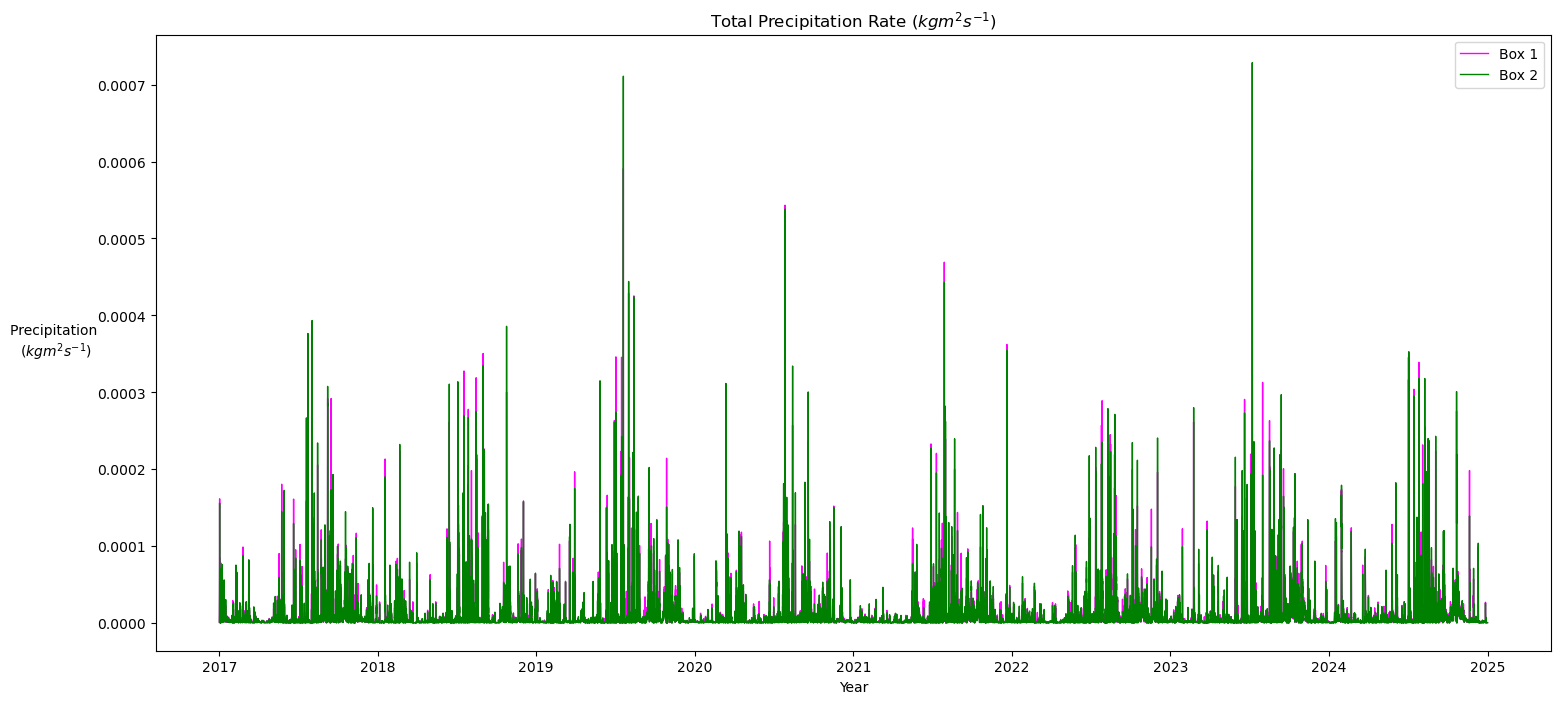

In [21]:
# Plot time series for these two regions (one panel for longwave
# and another for shortwave)

# Make the figure
fig, ax = plt.subplots(figsize=(18,8))

# Longwave
ax.plot(era5_precip.valid_time, precip_reg1_avg, color='magenta', linewidth=1, label='Box 1')
ax.plot(era5_precip.valid_time, precip_reg2_avg, color='green', linewidth=1, label='Box 2')
ax.set_title('Total Precipitation Rate ($kg m^{2} s^{-1}$)')
ax.set_ylabel('Precipitation \n($kg m^{2} s^{-1}$)', rotation=0, va='center', labelpad=30)
ax.legend()
ax.set_xlabel('Year')

In [16]:
# Make a version of the plot that has the average value
# for each day of each based on all of these years

# group by hour of day of year to rpeserve that frequency

# Box 1
precip_reg1_avg_doy_hrly = precip_reg1_avg.groupby(['valid_time.dayofyear', 'valid_time.hour']).mean('valid_time')
# Box 2
precip_reg2_avg_doy_hrly = precip_reg2_avg.groupby(['valid_time.dayofyear', 'valid_time.hour']).mean('valid_time')

In [17]:
# Reshape to be time series
# Dumb way would be to loop and we could just do that...
# Yup takes no time do the dumb way
# Box 1 
precip_reg1_avg_doy_hrly2 = np.empty((len(precip_reg1_avg_doy_hrly[:,0])*len(precip_reg1_avg_doy_hrly[0,:])))
# Box 2
precip_reg2_avg_doy_hrly2 = np.empty((len(precip_reg2_avg_doy_hrly[:,0])*len(precip_reg2_avg_doy_hrly[0,:])))

# Set the count for looping
count = 0

# Loop through day of year
for d in range(len(precip_reg1_avg_doy_hrly[:,0])):
    # Set the indices 
    start = count
    end = start + 24
    #print('start: ', start)
    #print('end: ', end)
 
    # Save this to the array
    # Box 1
    precip_reg1_avg_doy_hrly2[start:end] = precip_reg1_avg_doy_hrly[d,:]
    # Box 2
    precip_reg2_avg_doy_hrly2[start:end] = precip_reg2_avg_doy_hrly[d,:]

    # Increase the count
    #print('count before: ', count)
    count = count + 24
    #print('count after: ', count)

Text(0.5, 0, 'Day & Hour of Year')

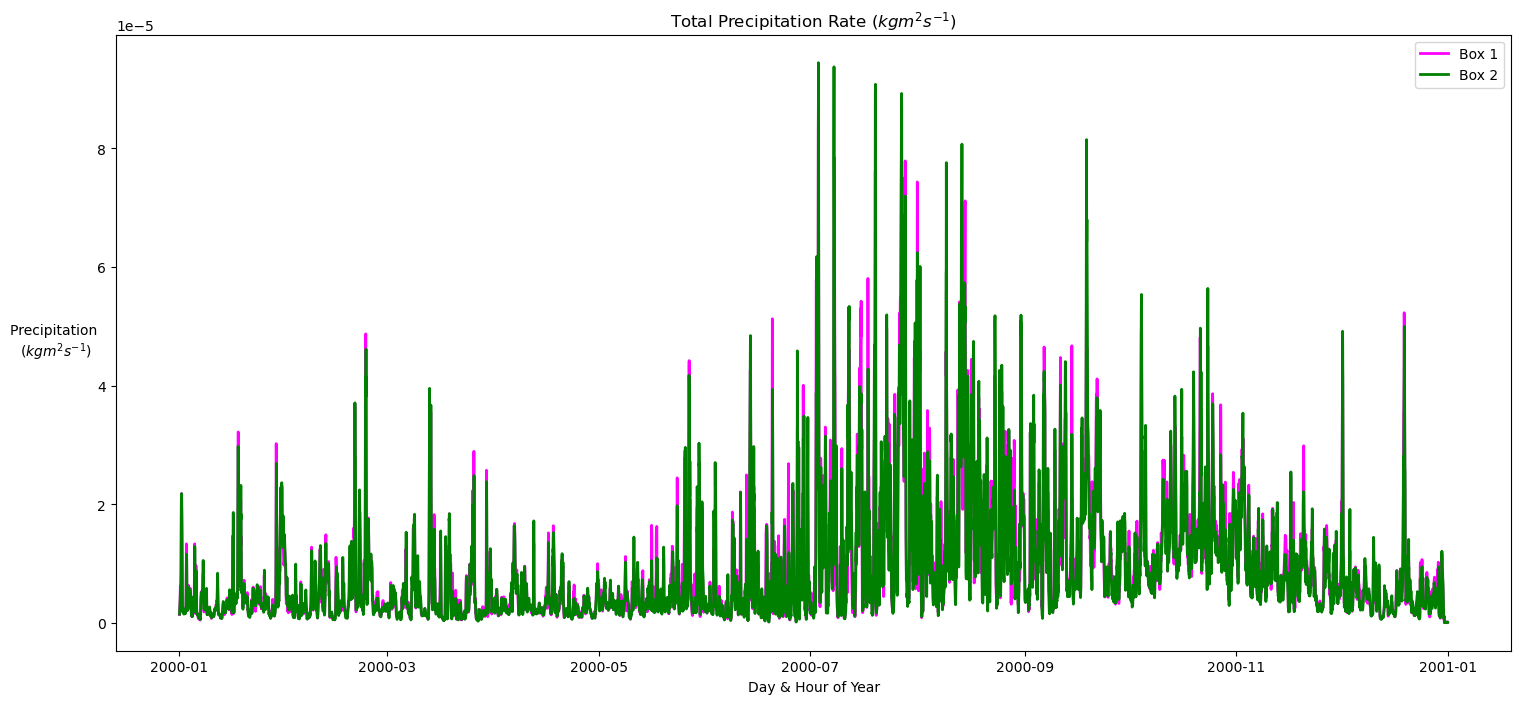

In [22]:
# Make day of year array
day_of_year = np.arange(1, 367, 1)

# Make new time index 
doy_w_hour = np.arange(1, 8785, 1)
hourly_datetimes = pd.date_range(start='2000-01-01', periods=366*24, freq='H')

# Make the figure
fig, ax = plt.subplots(figsize=(18,8))

# Longwave
ax.plot(hourly_datetimes, precip_reg1_avg_doy_hrly2, color='magenta', linewidth=2, label='Box 1')
ax.plot(hourly_datetimes, precip_reg2_avg_doy_hrly2, color='green', linewidth=2, label='Box 2')
ax.set_title('Total Precipitation Rate ($kg m^{2} s^{-1}$)')
ax.set_ylabel('Precipitation \n($kg m^{2} s^{-1}$)', rotation=0, va='center', labelpad=30)
ax.legend()
ax.set_xlabel('Day & Hour of Year')

Text(0.5, 0, 'Day & Hour of Year')

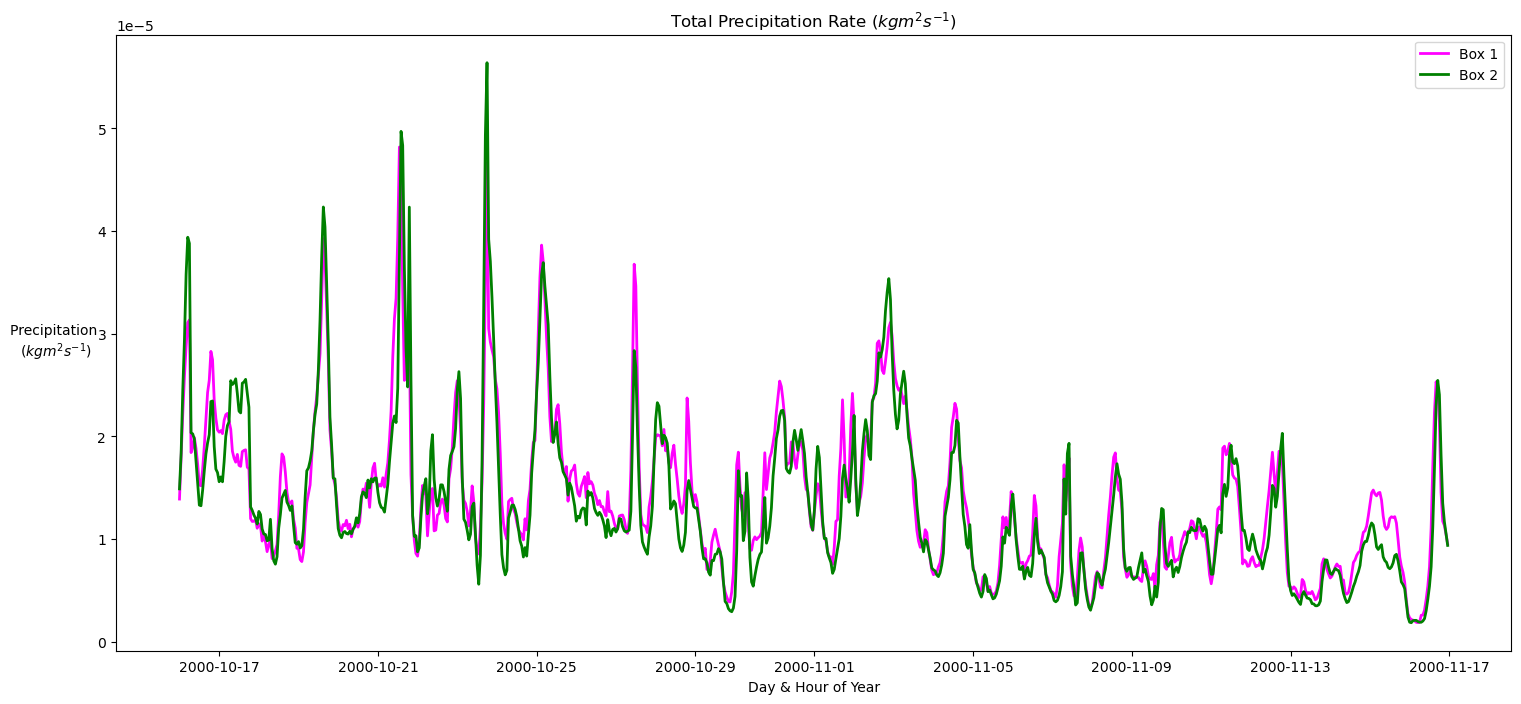

In [23]:
# Trim to just the period we want
# Plot the values around freeze-up which is mid-October to mid-November (ish)
# September 15 - October 15 = days 289 - 320 (leap year)

# Make the figure
fig, ax = plt.subplots(figsize=(18,8))

# Longwave
ax.plot(hourly_datetimes[289*24:321*24], precip_reg1_avg_doy_hrly2[289*24:321*24], color='magenta', linewidth=2, label='Box 1')
ax.plot(hourly_datetimes[289*24:321*24], precip_reg2_avg_doy_hrly2[289*24:321*24], color='green', linewidth=2, label='Box 2')
ax.set_title('Total Precipitation Rate ($kg m^{2} s^{-1}$)')
ax.set_ylabel('Precipitation \n($kg m^{2} s^{-1}$)', rotation=0, va='center', labelpad=30)
ax.legend()
ax.set_xlabel('Day & Hour of Year')

In [24]:
# Before fitting a sine curve to this, shift the data
# to start in mid-October to make it easier for fitting

precip_reg1_avg_doy_hrly2_oct_start_pt1 = precip_reg1_avg_doy_hrly2[((289*24)+1):]
precip_reg1_avg_doy_hrly2_oct_start_pt2 = precip_reg1_avg_doy_hrly2[:((289*24)+1)]

# Now combine/append these two parts to get a ~9 month time series 
precip_reg1_avg_doy_hrly2_oct_start = np.concatenate((precip_reg1_avg_doy_hrly2_oct_start_pt1, precip_reg1_avg_doy_hrly2_oct_start_pt2))

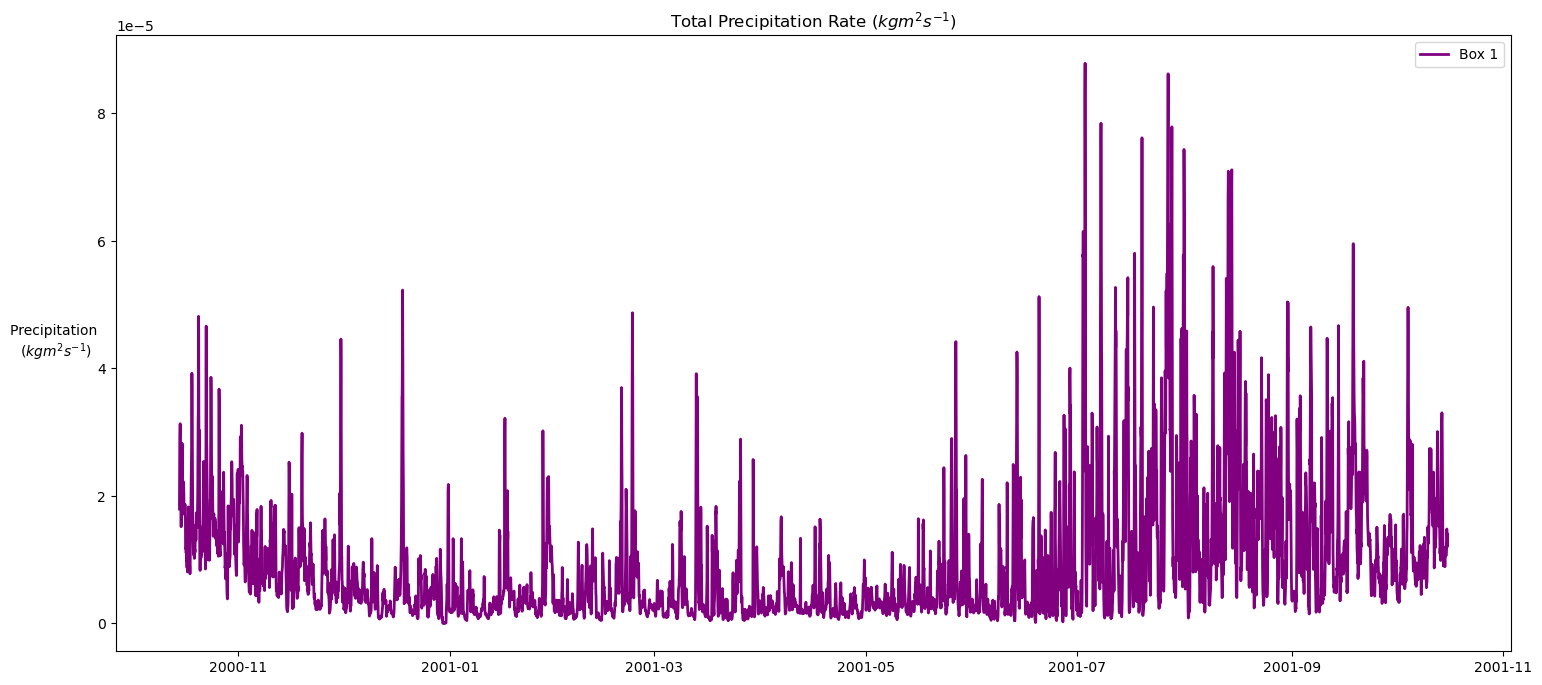

In [29]:
# Plot this to see how it looks

# Make shifted datetimes
hourly_datetimes_shifted = pd.date_range(start='2000-10-15', periods=366*24, freq='H')

# Plot the data
# Make the figure
fig, ax = plt.subplots(figsize=(18,8))

# Longwave
ax.plot(hourly_datetimes_shifted, precip_reg1_avg_doy_hrly2_oct_start, color='purple', linewidth=2, label='Box 1')

#ax.plot(hourly_datetimes, longwave_reg2_avg_doy_hrly2, color='green', linewidth=2, label='Box 2')
ax.set_title('Total Precipitation Rate ($kg m^{2} s^{-1}$)')
ax.set_ylabel('Precipitation \n($kg m^{2} s^{-1}$)', rotation=0, va='center', labelpad=30)
#ax.xaxis.set_visible(False)
ax.legend()

In [27]:
# For precipitation, make a sine wave fit 
# to use for idealized version
# Work on a fit...
# Focus on Box 1 since that is the one we will base everything 
# else on
from scipy.optimize import curve_fit

# Define a function to make an inital guess of a sine wave
def sine_function(x, amplitude, frequency, phase, offset):
        return amplitude * np.sin(frequency * x + phase) + offset

# Initial guess for parameters (amplitude, frequency, phase, offset)
initial_guess = [2, (1/(366*24)), 0, 1]

# Convert time to hours since initial date to help with sine fit
time0 = hourly_datetimes[0]
numeric_time = (hourly_datetimes - time0) / np.timedelta64(1, 'h')

# Calculate/Fit parameters based on real data and the initial guess
params, covariance = curve_fit(sine_function, numeric_time, precip_reg1_avg_doy_hrly2_oct_start, p0=initial_guess)

# Pull out the parameters
amplitude_fit, frequency_fit, phase_fit, offset_fit = params

# Use these new parameters to make a new sine function that fits the data
y_fit = sine_function(numeric_time, amplitude_fit, frequency_fit, phase_fit, offset_fit)

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.

In [28]:
# Okay so this times out because a sine curve is really not a great fit
# I think we leave it as-is because we do want the oscillations from 
# 0 to a value rather than some constant precipitation soooo
# leave this for now but can always do ana_rain=0 instead

In [30]:
# Now pull out 9 months starting at October
# (shifted above so no need to shift here)
no_fit_no_diurnal_reg1 = precip_reg1_avg_doy_hrly2_oct_start
idealized_precip_reg1 = no_fit_no_diurnal_reg1[:((289*24)+1)]

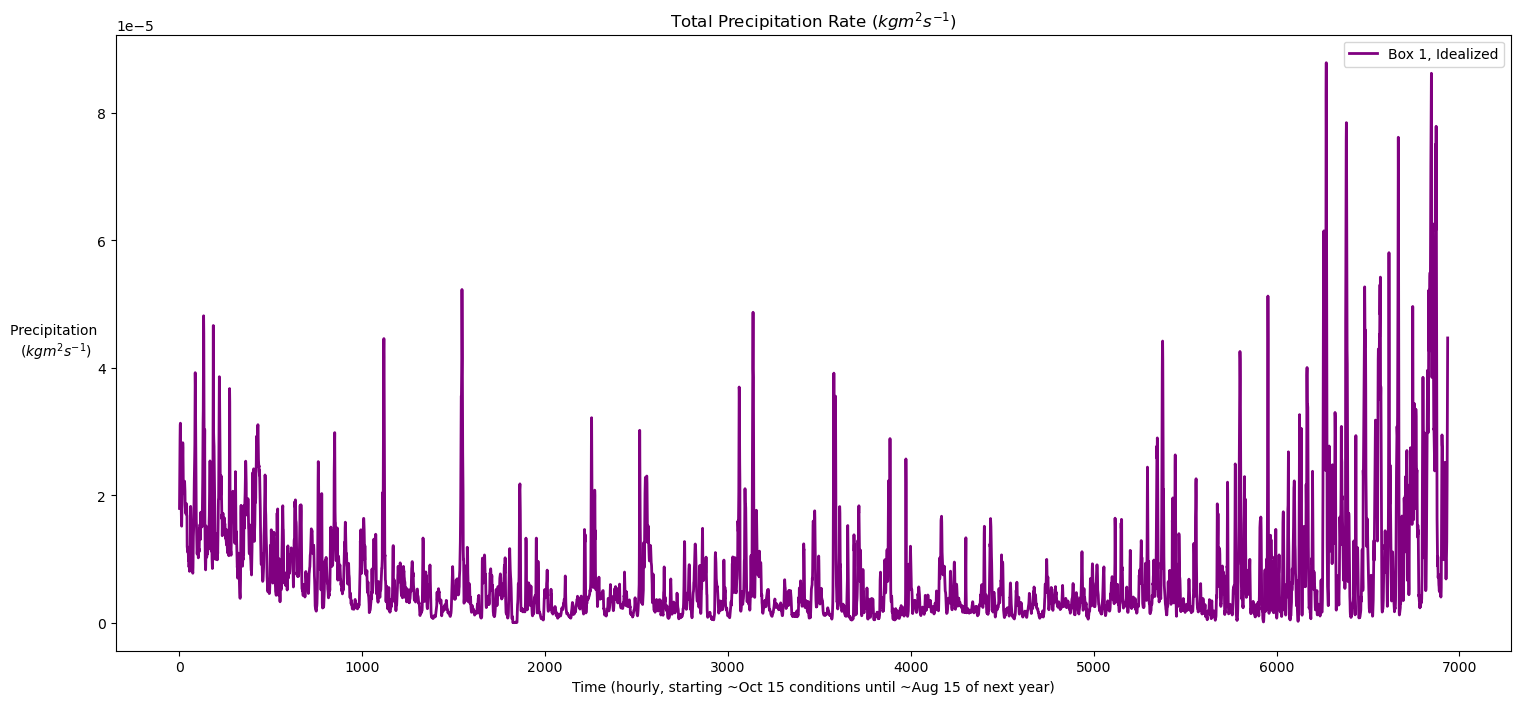

In [31]:
# Plot the idealized forcing 
# Make the figure
fig, ax = plt.subplots(figsize=(18,8))

# Longwave
ax.plot(idealized_precip_reg1, color='purple', linewidth=2, label='Box 1, Idealized')
ax.set_title('Total Precipitation Rate ($kg m^{2} s^{-1}$)')
ax.set_ylabel('Precipitation \n($kg m^{2} s^{-1}$)', rotation=0, va='center', labelpad=30)
ax.set_xlabel('Time (hourly, starting ~Oct 15 conditions until ~Aug 15 of next year)')
#ax.xaxis.set_visible(False)
ax.legend()

In [32]:
# Change any units as needed to match what ROMS wants/expects
# Check units 
print('ERA5 precipitation units: ', era5_precip.avg_tprate.units)

ERA5 precipitation units:  kg m**-2 s**-1


In [34]:
# Do some quality control checking 
# (min, max, mean, nans)
# Precipitation 
print('max precipitation: ', np.max(era5_precip.avg_tprate.values))
print('min precipitation: ', np.min(era5_precip.avg_tprate.values))
print('nan precipitation: ', np.where(np.isnan(era5_precip.avg_tprate.values)))

max precipitation:  0.0027157068
min precipitation:  0.0
nan precipitation:  (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))


### Set up the NetCDF  

The idealized model does not have any ties to lat/lon so the data can just be given in grid space rather than lat/lon and does not need to be interpolated or anything since it is spatially uniform. So we need to load the in the grid and then maybe remake this file any time you remake the grid.

In [35]:
# Load in the idealized model grid to get the dimensions 
# 500 m
#grid = xr.open_dataset('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_500m_002.nc')
# 1 km
grid = xr.open_dataset('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1km_span_500km_noise_001.nc')

In [36]:
grid

<xarray.Dataset> Size: 12MB
Dimensions:      (eta_rho: 502, xi_rho: 202, eta_psi: 501, xi_psi: 201,
                  eta_u: 502, xi_u: 201, eta_v: 501, xi_v: 202)
Dimensions without coordinates: eta_rho, xi_rho, eta_psi, xi_psi, eta_u, xi_u,
                                eta_v, xi_v
Data variables: (12/18)
    x_rho        (eta_rho, xi_rho) float64 811kB ...
    y_rho        (eta_rho, xi_rho) float64 811kB ...
    x_psi        (eta_psi, xi_psi) float64 806kB ...
    y_psi        (eta_psi, xi_psi) float64 806kB ...
    x_u          (eta_u, xi_u) float64 807kB ...
    y_u          (eta_u, xi_u) float64 807kB ...
    ...           ...
    angle        (eta_rho, xi_rho) float64 811kB ...
    spherical    bool 1B ...
    xl           float64 8B ...
    el           float64 8B ...
    visc_factor  (eta_rho, xi_rho) float64 811kB ...
    diff_factor  (eta_rho, xi_rho) float64 811kB ...

In [37]:
# Pull out grid dimensions 
# Read in the dimensions
# rho
eta_rho_len = len(grid.eta_rho) # 206
xi_rho_len = len(grid.xi_rho) # 608
print('eta_rho_len: ', eta_rho_len)
print('xi_rho_len: ', xi_rho_len)
# u
eta_u_len = len(grid.eta_u) # 206
xi_u_len = len(grid.xi_u) # 607
print('eta_u_len: ', eta_u_len)
print('xi_u_len: ', xi_u_len)
# v
eta_v_len = len(grid.eta_v) #
xi_v_len = len(grid.xi_v) # 
print('eta_v_len: ', eta_v_len)
print('xi_v_len: ', xi_v_len)

# Define other dimension lengths
# eta rho
Mp = len(grid.eta_rho)
# xi rho
Lp = len(grid.xi_rho)
print('Mp: ', Mp)
print('Lp: ', Lp)

# # latitude
# lat_u_len = len(grid.lat_u)
# lat_v_len = len(grid.lat_v)
# print('lat_u_len: ', lat_u_len)
# print('lat_v_len: ', lat_v_len)

# # longitude
# lon_u_len = len(grid.lon_u)
# lon_v_len = len(grid.lon_v)
# print('lon_u_len: ', lon_u_len)
# print('lon_v_len: ', lon_v_len)

eta_rho_len:  502
xi_rho_len:  202
eta_u_len:  502
xi_u_len:  201
eta_v_len:  501
xi_v_len:  202
Mp:  502
Lp:  202


In [39]:
# Need to make a time that is hours since some reference time 
# Get the length of time for the data

# convert all the times to seconds since the first time step so it is on generic time)
#time_tmp = ((hourly_datetimes_shifted[:] - datetime(0,12,31)).total_seconds() - 86400)
time_tmp_1 = ((hourly_datetimes_shifted[:] - hourly_datetimes_shifted[0]).total_seconds())
# Trim to just the time we want
time_tmp = time_tmp_1[:len(idealized_precip_reg1)]
# Get the length from this 
# time
time_len = len(time_tmp)

In [40]:
time_tmp

Index([       0.0,     3600.0,     7200.0,    10800.0,    14400.0,    18000.0,
          21600.0,    25200.0,    28800.0,    32400.0,
       ...
       24937200.0, 24940800.0, 24944400.0, 24948000.0, 24951600.0, 24955200.0,
       24958800.0, 24962400.0, 24966000.0, 24969600.0],
      dtype='float64', length=6937)

In [42]:
print('len time_tmp: ', len(time_tmp))
print('len hourly_datetimes_shifted: ', len(hourly_datetimes_shifted))
print('len idealized_air_temp_reg1: ', len(idealized_precip_reg1))

len time_tmp:  6937
len hourly_datetimes_shifted:  8784
len idealized_air_temp_reg1:  6937


In [43]:
# Make a version of the code that is this shape and same everywhere
idealized_precip_reg1_ongrid = np.empty((time_len, eta_rho_len, xi_rho_len))

# Loop through space and fill with the idealized version
for y in range(eta_rho_len):
    for x in range(xi_rho_len):
        idealized_precip_reg1_ongrid[:,y,x] = idealized_precip_reg1

# Could insert a check for this at some point...

In [46]:
# Make the netcdf for the forcing file 

# ------------------------------- Create the netCDF file ---------------------------

#name of file I am writing to
# 500 m
#tair_frc = '/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Forcing_files/idealized_precip_forcing_500m_002.nc'   #UPDATE PATH
# 1 km
precip_frc = '/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Forcing_files/idealized_precip_forcing_1km_span_500km_001.nc'   #UPDATE PATH

#create file to write to
nc1 = Dataset(precip_frc, 'w', format='NETCDF4')

#Global attributes
global_defaults = dict(gridname = '*.nc',
                      type = 'ROMS grid shaped ERA5 idealized precipitation forcing',
                      history = 'Created by Brianna Undzis',
                      Conventions = 'CF',
                      Institution = 'University of Colorado Boulder',
                      date = str(datetime.today()))
    
#create dictionary for model
d = {}
d = global_defaults

for att, value in d.items():
    setattr(nc1, att, value)

# Create dimensions
nc1.createDimension('xi_rho',  xi_rho_len)   # rho
nc1.createDimension('eta_rho', eta_rho_len)
# nc1.createDimension('lon',  era5_lon_len)   # rho
# nc1.createDimension('lat', era5_lat_len)
nc1.createDimension('rain_time', None)
nc1.createDimension('one',     1)

# Create variables 
# --------------------
# Coordinate Variables
# --------------------
# # era5 lon
# lon = nc1.createVariable('lon', 'd', ('lon',), zlib=True)
# lon.long_name = 'longitude coordinate of ERA5 data'
# lon.standard_name = 'projection_lon_coordinate'
# lon.units = 'degrees'
# lon_tmp = era5_longwave.longitude
# lon[:] = lon_tmp[:]

# # era5 lat
# lat = nc1.createVariable('lat', 'd', ('lat',), zlib=True)
# lat.long_name = 'latitude coordinate of ERA5 data'
# lat.standard_name = 'projection_lat_coordinate'
# lat.units = 'degrees'
# #lat_tmp = era5_longwave.latitude
# lat_tmp = lat_flip # FLIP
# lat[:] = lat_tmp[:]

# xi rho
xi_rho = nc1.createVariable('xi_rho', 'd', ('xi_rho',), zlib=True)
xi_rho.long_name = 'xi coordinate of RHO-points'
xi_rho.standard_name = 'projection_xi_coordinate'
xi_rho.units = 'meter'
xi_rho_tmp = np.arange(0, Lp)
xi_rho[:] = xi_rho_tmp[:]

# eta rho
eta_rho = nc1.createVariable('eta_rho', 'd', ('eta_rho',), zlib=True)
eta_rho.long_name = 'eta coordinate of RHO-points'
eta_rho.standard_name = 'projection_eta_coordinate'
eta_rho.units = 'meter'
eta_rho_tmp = np.arange(0, Mp)
eta_rho[:] = eta_rho_tmp[:]

# rain_time (in seconds)
rain_time_g = nc1.createVariable('rain_time', None, ('rain_time'), zlib=True)
rain_time_g.long_name = 'seconds since 2000-01-01 00:00:00' #with initialization of 2000-01-01 00:00:00
rain_time_g.units = 'second'
rain_time_g.field = 'time, scalar, series'
rain_time_g[:] = time_tmp[:]


# --------------------
# Atmospheric Variables 
# --------------------

# rain
rain_interp_g = nc1.createVariable('rain', 'f8', ('rain_time', 'eta_rho', 'xi_rho'), zlib=True, fill_value=1e30)
rain_interp_g.long_name = 'rain fall rate'
rain_interp_g.standard_name = 'precipitation_flux'
rain_interp_g.units = 'kiloegram meter-2 second-1'
rain_interp_g.coordinates = 'eta_rho xi_rho' 
rain_interp_g[:,:,:] = idealized_precip_reg1_ongrid[:,:,:]


nc1.close()
# ------------------------------- End netCDF ---------------------------

In [45]:
#nc1.close()